<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Clase 8 de Abril
#### Jeremias Martin Pantozzi


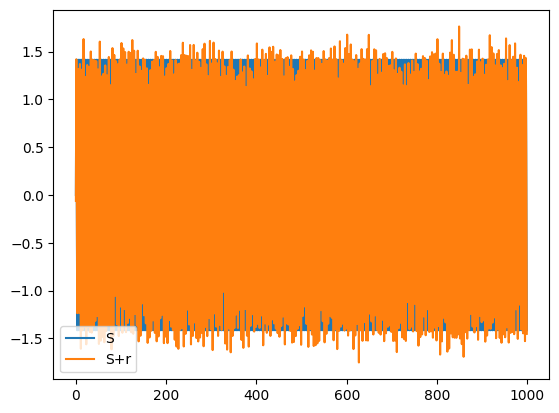

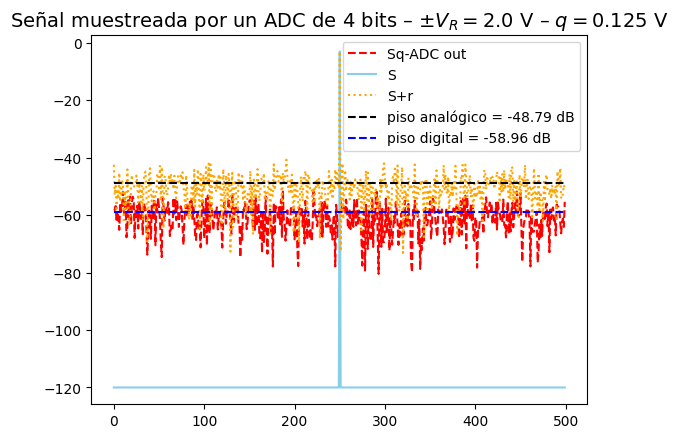

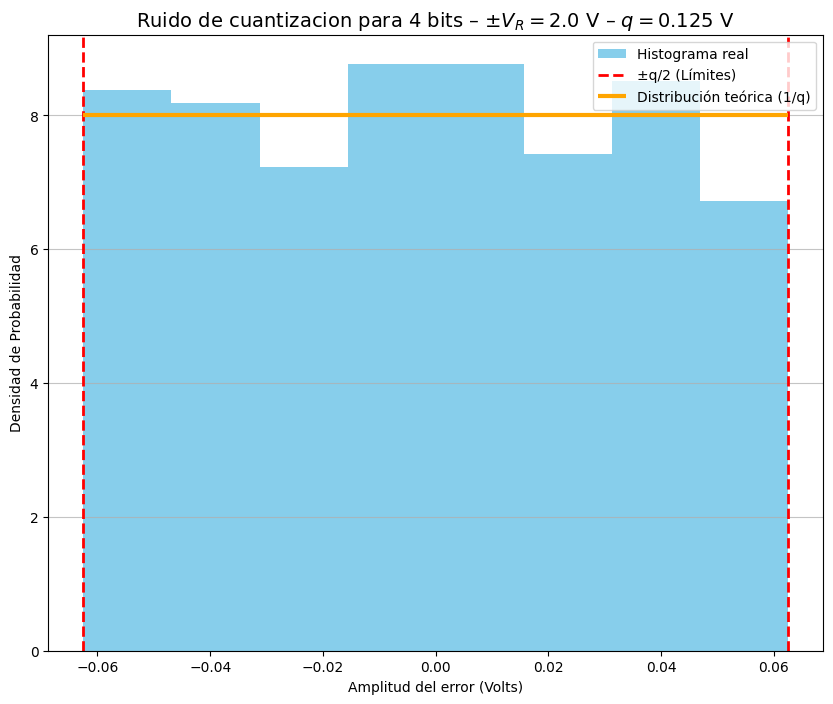

In [2]:
# -*- coding: utf-8 -*-
"""
Created on Wed Apr  8 19:19:22 2026

@author: jerem
"""
#%% Librerias
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import signal as sig

#%% funcion seno
def mi_funcion_sen (vmax, dc, ff, ph, nn, fs):
        tt= np.arange(nn)/fs
        xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
        return tt, xx
def mi_funcion_sen_normalizada(vmax, dc, k, nn, ph=0):
    n = np.arange(nn)
    xx = dc + vmax * np.sin(2 * np.pi * (k/nn) * n + ph)
    return n, xx


#%% ejecucion
nn = 1000
k = nn//4   # 250
#k=1
vmax = np.sqrt(2)
dc = 0
ph = 0

n, xx = mi_funcion_sen_normalizada(vmax, dc, k, nn, ph)


#%% Parametros de ADC
B = 4 #bits

Vfs = 2 #Volts

qq= Vfs / (2**B)

#%% funcion ruido segun dB pedido
kn=10
Pr=kn*(qq**2)/12
R= np.random.normal(0, np.sqrt(Pr), nn)


xxn=xx + R

plt.figure(1)
plt.clf()
plt.plot (xx, label ='S')
plt.plot(xxn, label = 'S+r')
plt.legend()

#%% fft


XX = np.fft.fft(xx)*1/nn #escalamos con 1/nn para ver W

XXmod= np.abs(XX)
XXphase= np.angle(XX)
XXmod_ad=(XXmod**2)#Ajustamos con factor de escala 2 porque tengo visualizado 1, por simetria la otra es igual

XXmod_dB = 10 * np.log10(XXmod_ad+1e-12) 


#%% fft señal + ruido

XXr = np.fft.fft(xxn)*1/nn

XXrmod= (np.abs(XXr)**2)
XXrphase= np.angle(XXr)



XXrmod_dB = 10 * np.log10(XXrmod)


#%% fft de cuantizacion

xxq= np.round(xxn/qq)*qq

exxq= xxq-xxn

vare=np.var(exxq)

varteoe=qq**2/12

XXq = np.fft.fft(exxq)*1/nn

XXqmod= (np.abs(XXq)**2)
XXqphase= np.angle(XXq)
XXqmod_dB = 10 * np.log10((XXqmod))



#%% piso analogico y digital
k_sig=k
XXrmod_pos = XXrmod[:nn//2]
XXqmod_pos = XXqmod[:nn//2]

mask = np.ones(nn//2, dtype=bool)
mask[k_sig] = False

piso_analog_lin  = np.mean(XXrmod_pos[mask])
piso_digital_lin = np.mean(XXqmod_pos[mask])


piso_analog_dB = 10*np.log10(piso_analog_lin)
piso_digital_dB = 10*np.log10(piso_digital_lin)



plt.figure(2)
plt.clf()
plt.title(r"Señal muestreada por un ADC de 4 bits – $\pm V_R = 2.0\ \text{V}$ – $q = %.3f\ \text{V}$" % qq, fontsize=14)
plt.plot (XXqmod_dB[:500], label = 'Sq-ADC out', color = 'red',linestyle='--')
plt.plot (XXmod_dB[:500], label = 'S', color = 'skyblue')
plt.plot (XXrmod_dB[:500], label = 'S+r', color = 'orange',linestyle='dotted')
plt.plot([piso_analog_dB]*500, color='black', linestyle='dashed', label=f'piso analógico = {piso_analog_dB:.2f} dB')
plt.plot([piso_digital_dB]*500, color='blue', linestyle='dashed', label=f'piso digital = {piso_digital_dB:.2f} dB')

plt.legend()


#%% HIstograma

plt.figure(3, figsize=(10, 8))
plt.clf()
plt.title(r"Ruido de cuantizacion para 4 bits – $\pm V_R = 2.0\ \text{V}$ – $q = %.3f\ \text{V}$" % qq, fontsize=14)

# Bins alineados exactamente con el rango teórico
nbins = 8
bins = np.linspace(-qq/2, qq/2, nbins+1)

counts, bins_edges, _ = plt.hist(
    exxq,
    bins=bins,
    density=True,
    color='skyblue',
    label='Histograma real'
)

# Límites teóricos
plt.axvline(-qq/2, color='red', linestyle='--', linewidth=2, label='±q/2 (Límites)')
plt.axvline(qq/2, color='red', linestyle='--', linewidth=2)

# Línea teórica uniforme
plt.hlines(1/qq, -qq/2, qq/2, color='orange', linewidth=3, label='Distribución teórica (1/q)')

plt.xlabel('Amplitud del error (Volts)')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.grid(axis='y', alpha=0.75)